# Chapter 65 — Activation Functions in ML

> **Prerequisites:** ch062–064 (Piecewise, Step, Sigmoid)
>
> **You will learn:**
> - Catalog the major activation functions used in neural networks
> - Understand why nonlinear activations are necessary
> - Compare saturating vs non-saturating activations
> - Implement and benchmark common activations
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Without activation functions, a multi-layer neural network collapses to a single linear transformation. Activation functions introduce **nonlinearity** — the capacity to model complex, non-linear relationships.

The major families:
- **Sigmoid / Tanh**: saturating, bounded. Risk: vanishing gradients for large |x|
- **ReLU** (Rectified Linear Unit): max(0, x). Non-saturating for x>0. Simple and effective
- **Leaky ReLU, ELU, SELU**: fix the 'dying ReLU' problem (neurons stuck at 0)
- **GELU, Swish**: smooth approximations to ReLU; used in transformers
- **Softmax**: multi-class probability output layer

**Dying ReLU problem**: if a neuron receives only negative inputs, it outputs 0 and has zero gradient — it never updates. Leaky ReLU (α·x for x<0) fixes this by keeping a small gradient for negative inputs.

*(Sigmoid introduced in ch064; piecewise structure from ch062)*

---

## 2. Intuition & Mental Models

**Physical analogy:** Transistors in electronics. A transistor with no threshold is a linear amplifier. Add a threshold (saturation) and you get nonlinear logic gates. Neural networks are the mathematical equivalent — stacked nonlinear gates.

**Computational analogy:** Activation functions are the "decision units" of a network. Without them, no matter how many layers you stack, the output is just a matrix product of the input — expressible as a single linear transform.

---

## 3. Visualization

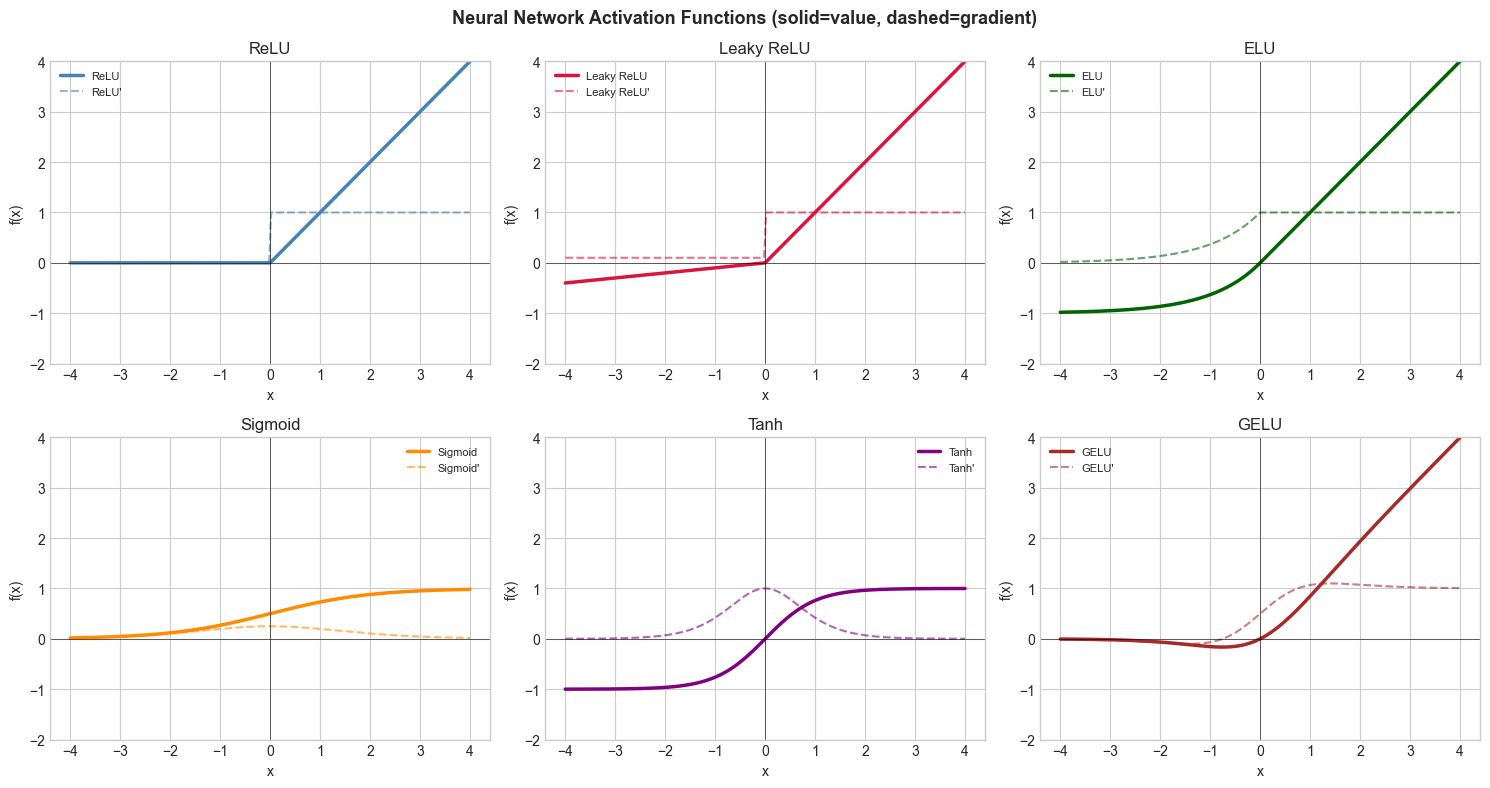

In [1]:
# --- Visualization: Activation function comparison ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-4, 4, 500)

def relu(x): return np.maximum(0, x)
def leaky_relu(x, a=0.1): return np.where(x >= 0, x, a * x)
def elu(x, a=1.0): return np.where(x >= 0, x, a * (np.exp(x) - 1))
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def gelu(x): return x * sigmoid(1.702 * x)  # fast approx
def swish(x): return x * sigmoid(x)

activations = [
    ('ReLU', relu, 'steelblue'),
    ('Leaky ReLU', leaky_relu, 'crimson'),
    ('ELU', elu, 'darkgreen'),
    ('Sigmoid', sigmoid, 'darkorange'),
    ('Tanh', tanh, 'purple'),
    ('GELU', gelu, 'brown'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, fn, color) in zip(axes.flat, activations):
    y = fn(x)
    dy = np.gradient(y, x)  # numerical derivative
    ax.plot(x, y, color=color, linewidth=2.5, label=name)
    ax.plot(x, dy, color=color, linewidth=1.5, linestyle='--', alpha=0.6, label=f"{name}'")
    ax.axhline(0, color='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.4)
    ax.set_title(name)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.set_ylim(-2, 4)
    ax.legend(fontsize=8)

plt.suptitle('Neural Network Activation Functions (solid=value, dashed=gradient)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: Activation benchmarking ---
import numpy as np
import time

ACTIVATIONS = {
    'relu':       lambda x: np.maximum(0, x),
    'sigmoid':    lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500))),
    'tanh':       np.tanh,
    'leaky_relu': lambda x: np.where(x >= 0, x, 0.1 * x),
    'elu':        lambda x: np.where(x >= 0, x, np.exp(np.minimum(x, 0)) - 1),
    'gelu':       lambda x: x * (1 / (1 + np.exp(-1.702 * x))),
}

def activation_gradient(fn, x, eps=1e-5):
    """Numerical gradient of activation function."""
    return (fn(x + eps) - fn(x - eps)) / (2 * eps)

# Benchmark speed
np.random.seed(0)
x_bench = np.random.randn(1000000)

print("Activation benchmarks (1M elements):")
for name, fn in ACTIVATIONS.items():
    t0 = time.time()
    _ = fn(x_bench)
    elapsed = (time.time() - t0) * 1000
    print(f"  {name:12s}: {elapsed:.2f} ms")

# Gradient check at x=1
print("\nGradient at x=1:")
for name, fn in ACTIVATIONS.items():
    g = activation_gradient(fn, np.array([1.0]))[0]
    print(f"  {name:12s}: {g:.4f}")

Activation benchmarks (1M elements):
  relu        : 5.81 ms
  sigmoid     : 45.32 ms
  tanh        : 23.83 ms
  leaky_relu  : 15.14 ms
  elu         : 39.00 ms
  gelu        : 39.73 ms

Gradient at x=1:
  relu        : 1.0000
  sigmoid     : 0.1966
  tanh        : 0.4200
  leaky_relu  : 1.0000
  elu         : 1.0000
  gelu        : 1.0678


---

## 6. Experiments

**Experiment 1:** Build a 2-layer network manually: `output = sigmoid(W2 @ relu(W1 @ x + b1) + b2)`. Replace relu with sigmoid in layer 1. Does the output change? (Yes — different activation = different learned function space.)

**Experiment 2:** Check the vanishing gradient problem: compute the gradient of sigmoid(sigmoid(sigmoid(x))) at x=0, x=2, x=5. Watch how the gradient magnitude drops with each sigmoid layer.

---

## 7. Exercises

**Easy 1.** Compute ReLU(-3), ReLU(0), ReLU(0.5). Write ReLU using only `max` (no `if`). *(Expected: 0, 0, 0.5)*

**Easy 2.** The Leaky ReLU with α=0 becomes standard ReLU. With α=1 it becomes the identity. Verify both cases.

**Medium 1.** Implement SELU: f(x) = λ(x if x>0, else α(e^x - 1)), where λ≈1.0507, α≈1.6733. These constants are chosen so that the function is self-normalizing. Test that mean and variance of SELU outputs are near 0 and 1 for standard normal input.

**Medium 2.** Plot the 'gradient landscape' of a 3-layer sigmoid network vs 3-layer ReLU network: for 1000 random inputs, compute the numerical gradient. Which maintains larger gradients deeper in the network?

**Hard.** Implement the Maxout activation: max(w₁ᵀx + b₁, w₂ᵀx + b₂). Show that ReLU is a special case of Maxout. Implement and verify on a simple 1D example.

---

## 9. Chapter Summary & Connections

- Nonlinear activations enable universal approximation — without them, deep networks = shallow linear transform
- Sigmoid/tanh saturate: gradients vanish for large |x|; ReLU doesn't saturate for x>0
- Dying ReLU problem: neurons with only negative inputs produce zero gradient forever
- GELU, Swish: smooth variants used in transformers and modern architectures

**Backward connection:** This unifies ch062–064 into a catalog of tools for ML practitioners.

**Forward connections:**
- ch215 (Chain Rule) explains why vanishing gradients are mathematically inevitable with saturating activations
- ch216 (Backpropagation) computes activation gradients layer by layer
- The full network is revisited in ch178 (Neural Network Layer Implementation)